In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\1_chain\3_comp
scenario=3comp_equal  K_MODEL=5  K_TRUE=3
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (1, 10000, 5, 4)
  HMC      mu (1, 10000, 5, 4)
  NUTS     mu (1, 10000, 5, 4)
  replication mu (1, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth, Grids (Full + Chebyshev) & Trimmed Mass ──────────
# Two grids per parameter, used by all cells below; the True DGP only enters the
# envelopes and stays an overlay in the plots.
#   "Full"      - min/max envelope over every component of every sampler + True
#                 DGP; nothing excluded, can be very wide.
#   "Chebyshev" - each model's pooled-marginal mean +/- 5*std (exact moments via
#                 the law of total variance), so >= 96% of each model's marginal
#                 mass is guaranteed inside for any distribution.
# Trimmed-mass tables report the realised trim EXACTLY (mixture CDF, no grid
# error) - equal to the renormalisation each density receives in Cell 5. The
# window is symmetric in x, not in mass: the left/right split shows the skew.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

for label, grids in GRIDS.items():
    trimmed = {m["name"]: (1.0 - mc.retained_mass(m, grids)) * 100.0
               for m in models + [true_model]}
    print(f"\nMass trimmed by the [{label}] window, in % of each marginal:")
    display(pd.DataFrame(trimmed, index=param_names).T.round(4))

cheb = GRIDS["Chebyshev (k=5, >=96%)"]
split = {}
for m in models + [true_model]:
    l, r = mc.trimmed_tails(m, cheb)
    split[m["name"]] = np.r_[l, r] * 100.0
cols = pd.MultiIndex.from_product([["left tail", "right tail"], param_names])
print("\nChebyshev trim by side, in % of each marginal:")
display(pd.DataFrame(split, index=cols).T.round(4))

Grid extents [Full]:
  Alt1       [-1961.91, +2242.81]
  Alt2       [-550.07, +571.10]
  Alt3       [-261.40, +293.46]
  Price      [-279.57, +340.89]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-14.99, +20.88]
  Alt2       [-16.29, +17.54]
  Alt3       [-7.76, +12.73]
  Price      [-20.13, +12.80]



Mass trimmed by the [Full] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0,0.0,0.0,0.0
HMC,0.0,0.0,0.0,0.0
NUTS,0.0,0.0,0.0,0.0
replication,0.0,0.0,0.0,0.0
True DGP,0.0,0.0,0.0,0.0



Mass trimmed by the [Chebyshev (k=5, >=96%)] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0076,0.0089,0.0387,0.0119
HMC,0.2698,0.1269,0.2998,0.0722
NUTS,0.1491,0.0954,0.2257,0.0817
replication,0.0087,0.0095,0.0371,0.0172
True DGP,0.0000,0.0000,0.0000,0.0000



Chebyshev trim by side, in % of each marginal:


left tail                         right tail                  \
                 Alt1    Alt2    Alt3   Price       Alt1    Alt2    Alt3   
bayesm         0.0050  0.0054  0.0297  0.0031     0.0026  0.0036  0.0089   
HMC            0.0523  0.0772  0.2161  0.0041     0.2176  0.0497  0.0837   
NUTS           0.0630  0.0440  0.0977  0.0497     0.0862  0.0514  0.1280   
replication    0.0055  0.0062  0.0243  0.0100     0.0032  0.0033  0.0127   
True DGP       0.0000  0.0000  0.0000  0.0000     0.0000  0.0000  0.0000   

                     
              Price  
bayesm       0.0089  
HMC          0.0681  
NUTS         0.0320  
replication  0.0072  
True DGP     0.0000

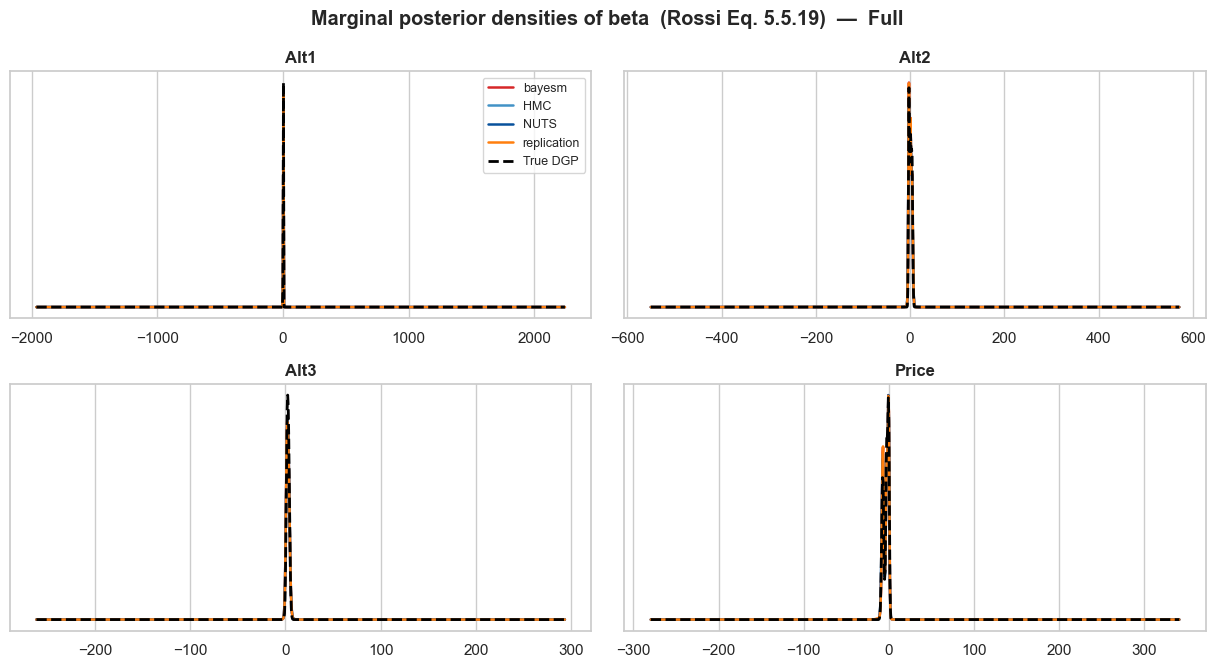

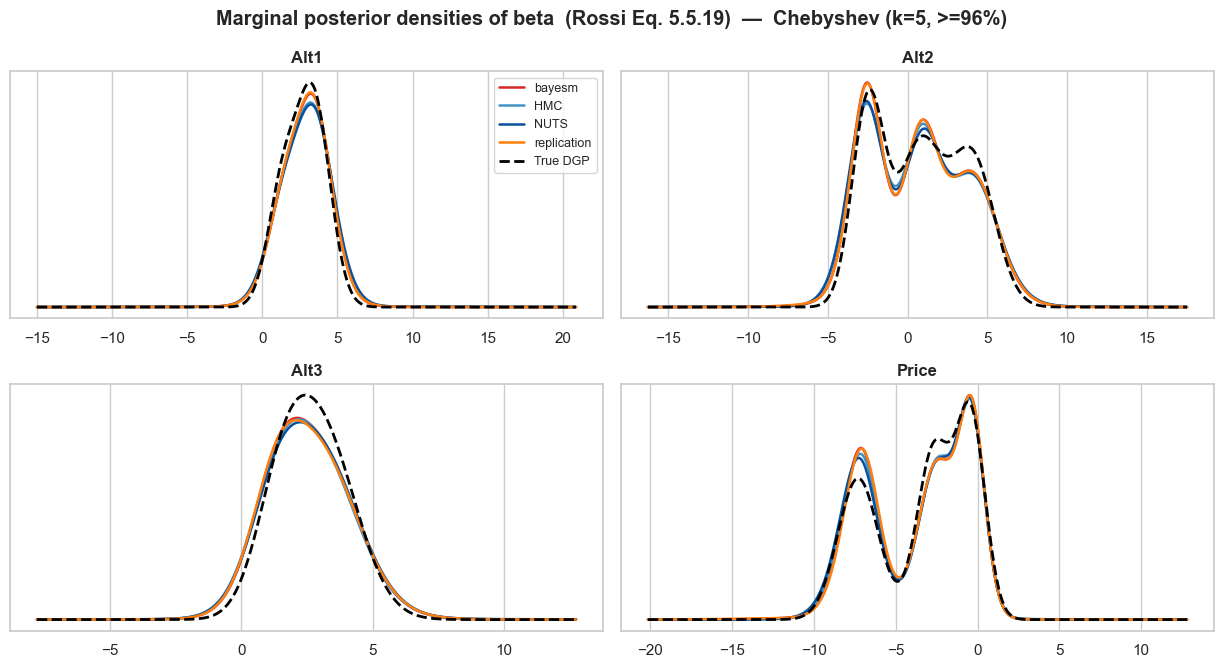

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev ──────────
# One figure per grid pass; True DGP dashed black, bayesm red, replication
# orange, Liesel gradient samplers in blues. Densities are cached in
# DENS/DENS_TRUE and reused by Cell 5.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "bayesm": "#d62728", "replication": "#ff7f0e"}
TRUE_COLOR = "#000000"
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name, d in dens.items():
            ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
        ax[j].set_title(pj, fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Marginal posterior densities of beta  (Rossi Eq. 5.5.19)  —  {label}",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev ──────────
# Each sampler vs the True DGP only (never sampler-vs-sampler): Hellinger
# (primary), KL(model||true), JSD, TVD, Wasserstein-1. Reuses DENS/DENS_TRUE.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:316: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.05331  0.06219  0.00245  0.02704       0.12305
            Alt2     0.07564      inf  0.00528  0.06207       0.24079
            Alt3     0.07974      inf  0.00601  0.07242       0.19959
            Price    0.05925      inf  0.00319  0.05529       0.18707
HMC         Alt1     0.08146      inf  0.00549  0.04614       0.31641
            Alt2     0.09373      inf  0.00791  0.06972       0.30993
            Alt3     0.09743      inf  0.00849  0.07827       0.27617
            Price    0.05387      inf  0.00255  0.04727       0.19161
NUTS        Alt1     0.08541      inf  0.00602  0.04719       0.26441
            Alt2     0.09361      inf  0.00795  0.06982       0.30236
            Alt3     0.09532      inf  0.00813  0.07377       0.23853
            Price    0.05842      inf  0.00287  0.04594       0.24282
replication Alt1     0.05786  0.07260  0.00284  0.02696       0.12354
            Alt2     0.07944      inf  0.00569  0.06194       0.24737
            Alt3     0.08374      inf  0.00664  0.07720       0.20949
            Price    0.06794      inf  0.00404  0.05952       0.19317

--- Chebyshev (k=5, >=96%) ---


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.07546  0.06432  0.00522  0.05411       0.17334
            Alt2     0.07536  0.04434  0.00525  0.06279       0.23868
            Alt3     0.07853  0.03677  0.00588  0.07141       0.19268
            Price    0.05874  0.03819  0.00315  0.05609       0.18433
HMC         Alt1     0.09140  0.19843  0.00749  0.06657       0.21719
            Alt2     0.09031  0.08675  0.00748  0.06776       0.27874
            Alt3     0.08947  0.05935  0.00746  0.07590       0.21905
            Price    0.05041  0.04536  0.00230  0.04704       0.17600
NUTS        Alt1     0.10326  0.23039  0.00952  0.07690       0.26033
            Alt2     0.09105  0.08715  0.00762  0.06866       0.27847
            Alt3     0.08925  0.06238  0.00735  0.07331       0.20560
            Price    0.05483  0.07428  0.00259  0.04525       0.22673
replication Alt1     0.07620  0.07032  0.00526  0.05166       0.17300
            Alt2     0.07916  0.06105  0.00566  0.06264       0.24607
            Alt3     0.08264  0.04077  0.00651  0.07625       0.20296
            Price    0.06731  0.06634  0.00398  0.05984       0.19126

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent (analytic in the draws); runs once.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.833,2.942,2.899,2.837,2.719
Alt2,0.620,0.596,0.624,0.617,0.781
Alt3,2.521,2.482,2.564,2.526,2.635
Price,-3.621,-3.597,-3.668,-3.623,-3.454


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.701,12.788,5.412,2.721,2.072
Alt2,9.823,11.333,11.384,9.929,8.600
Alt3,2.755,4.172,3.701,2.755,1.993
Price,9.824,10.580,10.786,9.922,9.352


In [7]:
# ── Cell 7 : Convergence of the Marginals - Goose-identical functional diagnostics ──────────
# az.rhat (rank) / az.ess (bulk, tail) - the exact calls in Goose's summary() -
# on grid-free functionals of each per-draw marginal: mean, sd, q05/q50/q95.
# ESS/s divides by the fit's total wall-clock (meta.json duration_s, incl.
# warmup). Read ESS only where R-hat ~ 1. Alternatives: mc.curve_diagnostics,
# mc.density_series_diagnostics.
if CHAINS == 1:
    print("NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.\n")

for m in models:
    rt = m.get("duration_s")
    print(f"--- {m['name']}" + (f"  (fit wall-clock: {rt:,.0f}s)" if rt else "") + " ---")
    display(mc.functional_diagnostics(m, param_names).round(3))

NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.

--- bayesm  (fit wall-clock: 219s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.003   338.398  1469.198       1.543       6.699
      sd          1.005   469.654  1784.638       2.142       8.138
      q05         1.004  1063.117  2132.983       4.848       9.726
      q50         1.006   412.761  1582.679       1.882       7.217
      q95         1.003   318.085   865.957       1.450       3.949
Alt2  mean        1.005   491.586  2090.515       2.242       9.533
      sd          1.007   252.320   325.849       1.151       1.486
      q05         1.039    60.683    44.465       0.277       0.203
      q50         1.001   443.706   938.349       2.023       4.279
      q95         1.002   308.373   624.781       1.406       2.849
Alt3  mean        1.003   512.056  2308.230       2.335      10.525
      sd          1.001   478.675  1185.169       2.183       5.404
      q05         1.002  1003.728  2693.395       4.577      12.282
      q50         1.008   390.738  1697.538       1.782       7.741
      q95         1.001   323.395   770.475       1.475       3.513
Price mean        1.012   249.111   456.283       1.136       2.081
      sd          1.049    36.751    49.330       0.168       0.225
      q05         1.055    33.795    31.021       0.154       0.141
      q50         1.001  2954.958  6946.704      13.475      31.677
      q95         1.001  4304.635  6907.960      19.629      31.500

--- HMC  (fit wall-clock: 291s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.150    11.167    33.979       0.038       0.117
      sd          1.251     6.109    12.850       0.021       0.044
      q05         1.019   201.094   573.891       0.692       1.973
      q50         1.015   117.855   269.370       0.405       0.926
      q95         1.023   113.894   357.569       0.392       1.230
Alt2  mean        1.029   105.587   423.706       0.363       1.457
      sd          1.035    54.141   120.692       0.186       0.415
      q05         1.029    66.693   288.539       0.229       0.992
      q50         1.034    93.206   584.110       0.321       2.009
      q95         1.010    75.122   253.528       0.258       0.872
Alt3  mean        1.029    69.744   129.069       0.240       0.444
      sd          1.048    44.991   144.684       0.155       0.498
      q05         1.017   243.232   408.190       0.836       1.404
      q50         1.002   200.449   616.229       0.689       2.119
      q95         1.002   103.214   151.941       0.355       0.522
Price mean        1.045    76.223   291.535       0.262       1.003
      sd          1.058    39.838    46.185       0.137       0.159
      q05         1.058    42.646    65.395       0.147       0.225
      q50         1.002   351.739  1846.349       1.210       6.349
      q95         1.028   128.122   535.941       0.441       1.843

--- NUTS  (fit wall-clock: 1,093s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.001   131.465   422.183       0.120       0.386
      sd          1.015   214.510   311.043       0.196       0.285
      q05         1.004   452.660  1078.665       0.414       0.987
      q50         1.004   256.998   730.936       0.235       0.669
      q95         1.007   122.749   386.892       0.112       0.354
Alt2  mean        1.005   309.106  1564.946       0.283       1.432
      sd          1.005   274.193   462.666       0.251       0.423
      q05         1.003   256.250   628.581       0.235       0.575
      q50         1.018   128.746   215.411       0.118       0.197
      q95         1.004   222.853   779.618       0.204       0.714
Alt3  mean        1.006   188.975   245.146       0.173       0.224
      sd          1.042    53.872   760.161       0.049       0.696
      q05         1.007   497.048  1197.914       0.455       1.096
      q50         1.004   290.216   528.374       0.266       0.484
      q95         1.005   261.837   788.315       0.240       0.722
Price mean        1.019   122.109   130.846       0.112       0.120
      sd          1.022    79.116   483.584       0.072       0.443
      q05         1.013   144.580   325.717       0.132       0.298
      q50         1.003   865.014  3273.590       0.792       2.996
      q95         1.007   422.107  1321.867       0.386       1.210

--- replication  (fit wall-clock: 202s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.038    50.572   714.944       0.250       3.536
      sd          1.032   188.857  1155.352       0.934       5.714
      q05         1.001   602.581  1818.535       2.980       8.994
      q50         1.013   401.740  1915.902       1.987       9.475
      q95         1.071    26.937    63.358       0.133       0.313
Alt2  mean        1.007   330.069  1039.278       1.632       5.140
      sd          1.061    31.972   130.630       0.158       0.646
      q05         1.093    17.543    26.018       0.087       0.129
      q50         1.005   548.904  1692.132       2.715       8.369
      q95         1.011   342.487   718.298       1.694       3.552
Alt3  mean        1.022   163.147   425.385       0.807       2.104
      sd          1.034    61.563  1219.302       0.304       6.030
      q05         1.003   746.528  1774.378       3.692       8.775
      q50         1.009   621.700  1519.808       3.075       7.516
      q95         1.048    45.041   160.506       0.223       0.794
Price mean        1.041    39.872   142.411       0.197       0.704
      sd          1.122    13.726    30.506       0.068       0.151
      q05         1.134    11.344    23.228       0.056       0.115
      q50         1.000  3010.405  6979.732      14.888      34.519
      q95         1.000  5177.794  7916.776      25.607      39.153

In [8]:
# ── Cell 8 : Notes ──────────
print("Notes:")
print(" - All quantities are label-invariant: relabeling/ECR would not change them.")
print(" - Grids: 'Full' = unbounded envelope over every component + True DGP;")
print("   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).")
print(" - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail")
print("   ESS) on grid-free functionals of each per-draw marginal.")
print(" - 1-chain runs: chains split into halves - a within-chain check only.")
print("   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).")

Notes:
 - All quantities are label-invariant: relabeling/ECR would not change them.
 - Grids: 'Full' = unbounded envelope over every component + True DGP;
   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).
 - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail
   ESS) on grid-free functionals of each per-draw marginal.
 - 1-chain runs: chains split into halves - a within-chain check only.
   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).
